In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import ee
import geemap
import rasterio as rio
import numpy as np
import geopandas as gpd
import seaborn2 as sns
from itertools import product

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/Users/edliao/miniconda/envs/research/lib/python3.10/site-packages/google/api_core/_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.16) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [3]:
ee.Authenticate()
ee.Initialize(project='earth-intelligence-492621')

# Getting assets from GEE

In [1]:
import os
import ee, geemap
from itertools import product

ee.Initialize(project='earth-intelligence-492621')

os.makedirs('../../data/gcvi', exist_ok=True)

years = list(range(2013, 2025))
types = ['raw', 'esri', 'jordi']

# already downloaded — flip to `states = DONE_STATES + NEW_STATES` to re-pull everything
DONE_STATES = [
    'telangana', 'maharashtra', 'karnataka', 'andhra_pradesh', 'tamil_nadu',
    'odisha', 'jharkhand', 'sikkim', 'assam', 'manipur', 'haryana', 'tripura',
]

# new exports — keys must match the `key` field in the GEE STATE_CONFIGS script
NEW_STATES = [
    'bihar', 'chhattisgarh', 'gujarat', 'himachal_pradesh', 'kerala',
    'meghalaya', 'mizoram', 'nagaland', 'rajasthan', 'uttarakhand',
    'goa', 'puducherry', 'chandigarh', 'lakshadweep',
    'arunachal_pradesh', 'andaman_nicobar', 'dadra_nagar_haveli', 'delhi',
]

states = NEW_STATES

skipped, failed, downloaded = 0, [], 0

for year, mask_type, state in product(years, types, states):
    filename = f'../../data/gcvi/peak_gcvi_kharif_{year}_{state}_{mask_type}.tif'

    if os.path.exists(filename):
        skipped += 1
        continue

    asset_id = f'projects/earth-intelligence-492621/assets/peak_gcvi_kharif_{year}_{state}_{mask_type}'
    try:
        peak_gcvi = ee.Image(asset_id)
        geemap.ee_export_image(
            peak_gcvi,
            filename=filename,
            scale=500,
            crs='EPSG:4326',
            region=peak_gcvi.geometry(),
        )
        downloaded += 1
    except Exception as e:
        # asset not exported yet, or no jordi crop map for this state
        failed.append((year, state, mask_type, str(e).split('\n')[0][:120]))

print(f"\nDownloaded: {downloaded}   Skipped (already on disk): {skipped}   Failed: {len(failed)}")
if failed:
    print("\nFailures:")
    for year, state, mask_type, msg in failed:
        print(f"  {year} {state:<20} {mask_type:<6} {msg}")

/Users/edliao/miniconda/envs/research/lib/python3.10/site-packages/google/api_core/_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.16) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Generating URL ...
Please wait ...
Data downloaded to /Users/edliao/Documents/6_Projects/crop-yield-forecasting/data/gcvi/peak_gcvi_kharif_2013_bihar_raw.tif
Generating URL ...
Please wait ...
Data downloaded to /Users/edliao/Documents/6_Projects/crop-yield-forecasting/data/gcvi/peak_gcvi_kharif_2013_chhattisgarh_raw.tif
Generating URL ...
Please wait ...
Data downloaded to /Users/edliao/Documents/6_Projects/crop-yield-forecasting/data/gcvi/peak_gcvi_kharif_2013_gujarat_raw.tif
Generating URL ..

# Aggregating TIFF files into GCVI mean per district

# Check GCVI TIF File/s

Min: -inf
Max: 31.736841201782227
Shape: (356, 265)


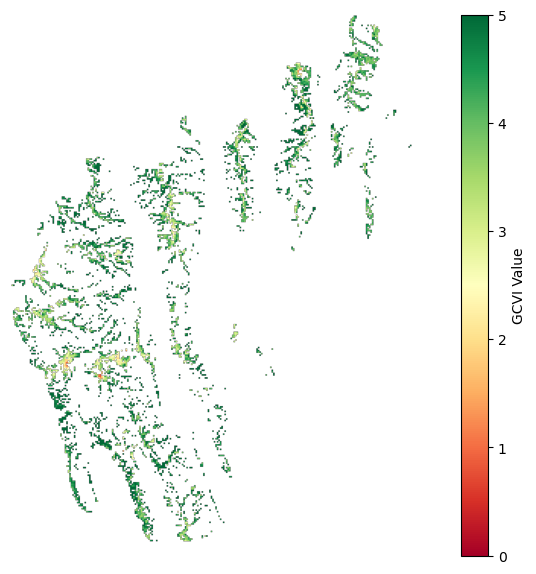

In [5]:
with rio.open('../../data/gcvi/peak_gcvi_kharif_2017_tripura_esri.tif') as src:
    data = src.read(1)

    # Handle no data values
    data[data == src.nodata] = np.nan

    # Print basic statistics of the data
    print(f"Min: {np.nanmin(data)}")
    print(f"Max: {np.nanmax(data)}")
    print(f"Shape: {data.shape}")

# Visualize the data
plt.figure(figsize=(10, 6))
# Use a colormap that clearly shows the range of values
plt.imshow(data, cmap='RdYlGn', vmin=0, vmax=5)
plt.colorbar(label='GCVI Value')
plt.tight_layout()
# plt.title('Peak GCVI Kharif 2024 - West Bengal (Raw)')
plt.axis('off')
plt.show()

In [8]:
np.unique(data)

array([          -inf, -4.9878347e-01, -4.8049647e-01, ...,
        7.1700000e+02,  7.3700000e+02,  8.2800000e+02], dtype=float32)

# TIF Visualization — Raw → ESRI → Crop mask per State

/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_29390/873178766.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


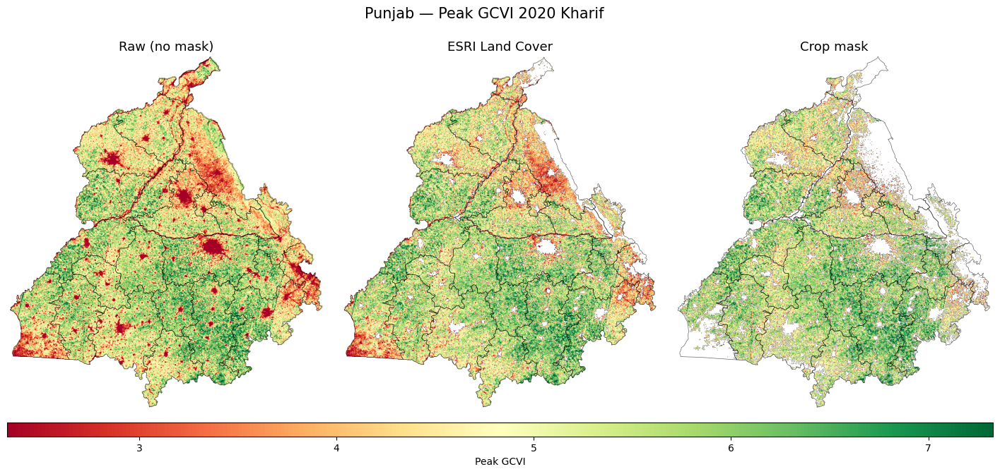

  Saved outputs/tif_viz_punjab.png


/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_29390/873178766.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


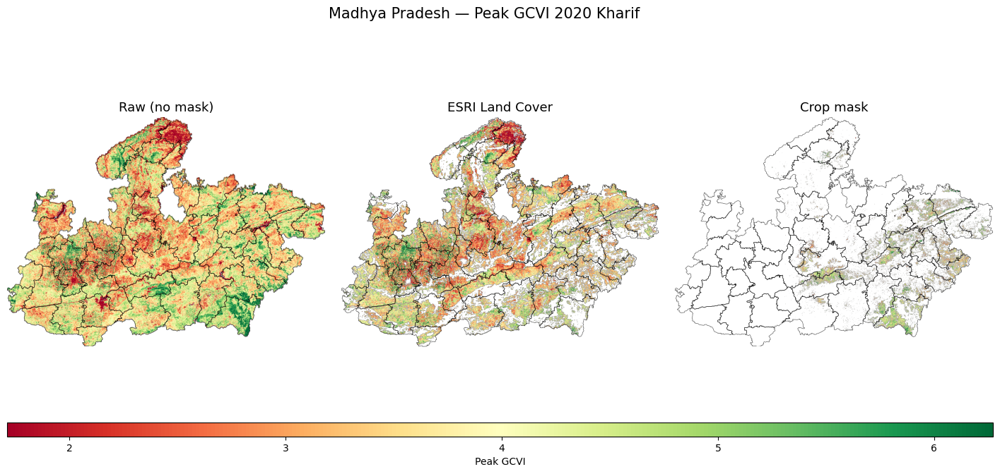

  Saved outputs/tif_viz_mp.png


/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_29390/873178766.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


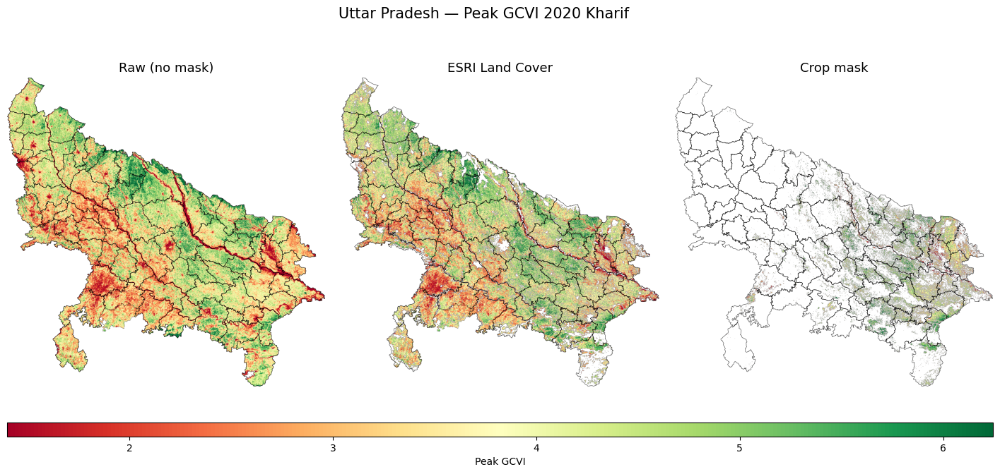

  Saved outputs/tif_viz_up.png


/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_29390/873178766.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


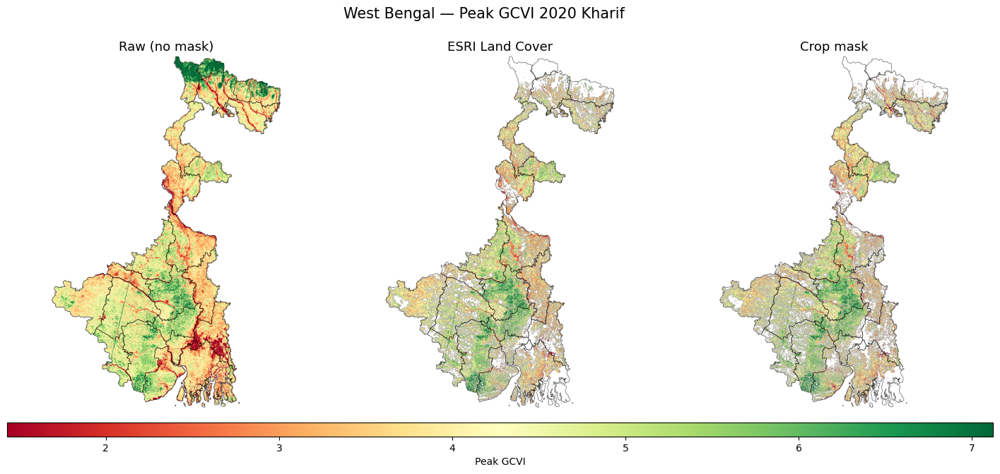

  Saved outputs/tif_viz_wb.png


/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_29390/873178766.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


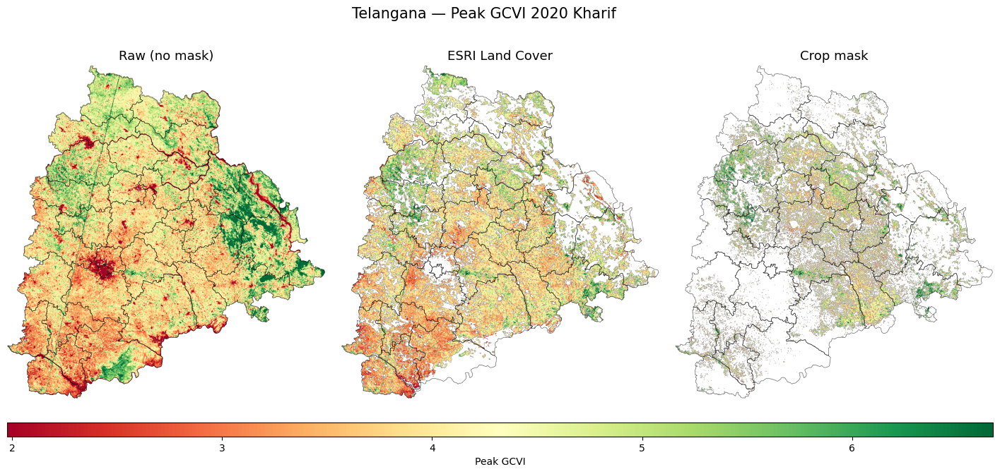

  Saved outputs/tif_viz_telangana.png


/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_29390/873178766.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


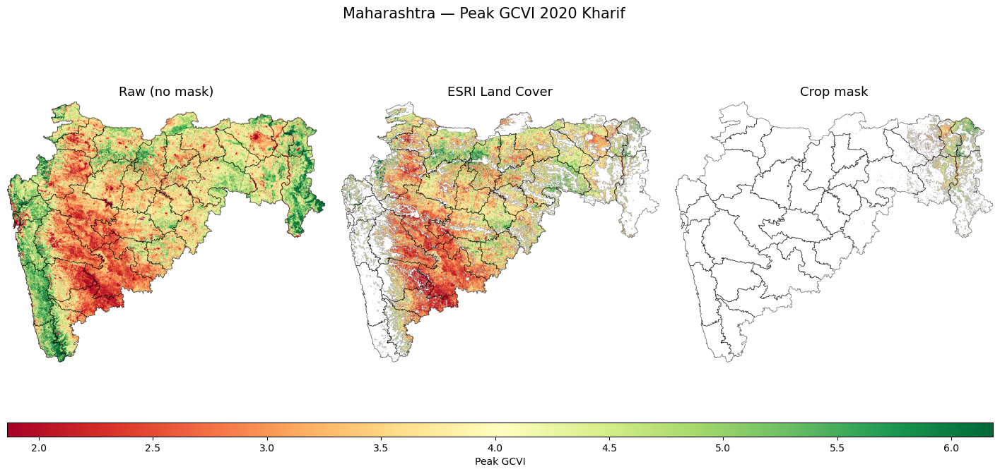

  Saved outputs/tif_viz_maharashtra.png


/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_29390/873178766.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


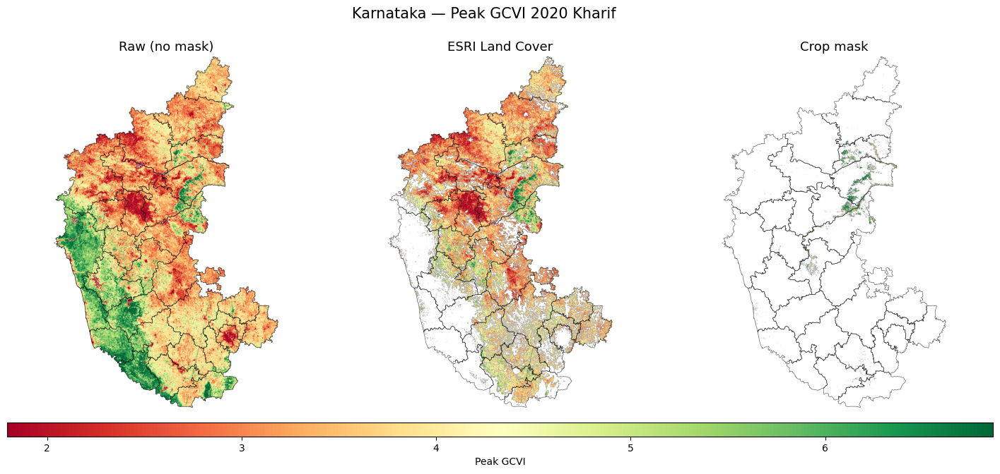

  Saved outputs/tif_viz_karnataka.png


/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_29390/873178766.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


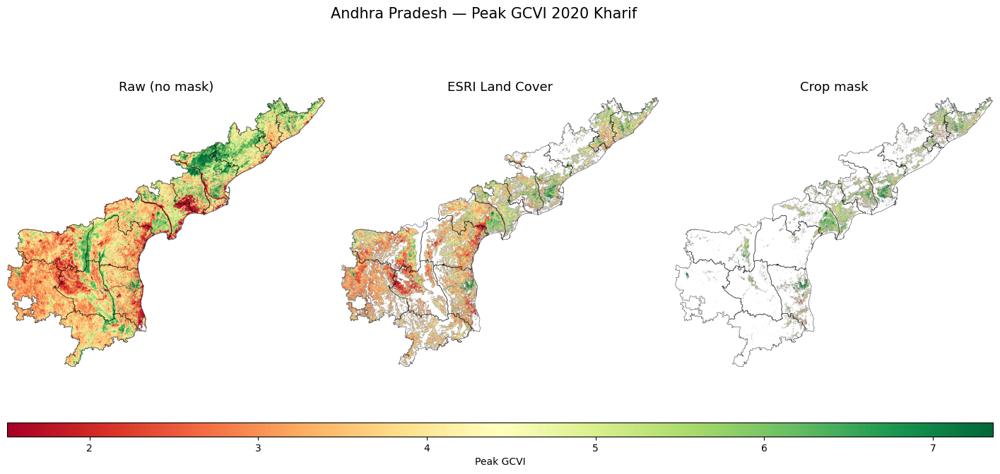

  Saved outputs/tif_viz_andhra_pradesh.png


/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_29390/873178766.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


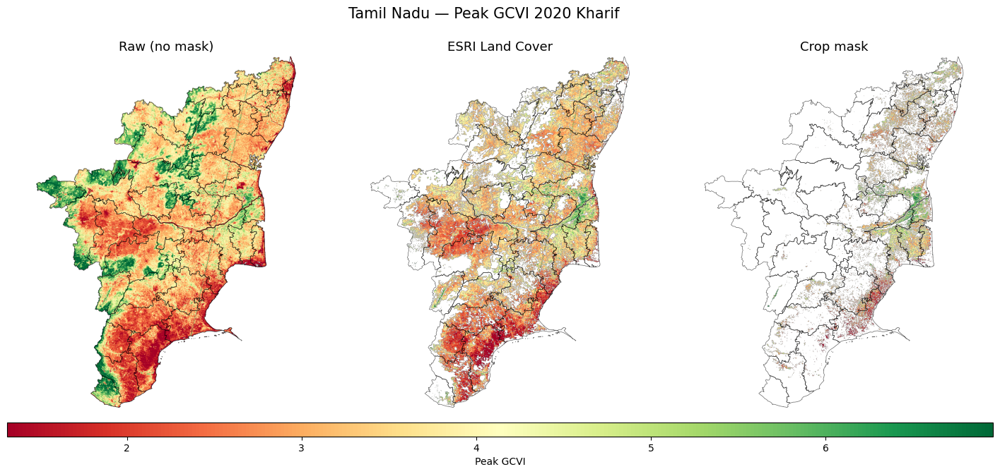

  Saved outputs/tif_viz_tamil_nadu.png


/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_29390/873178766.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


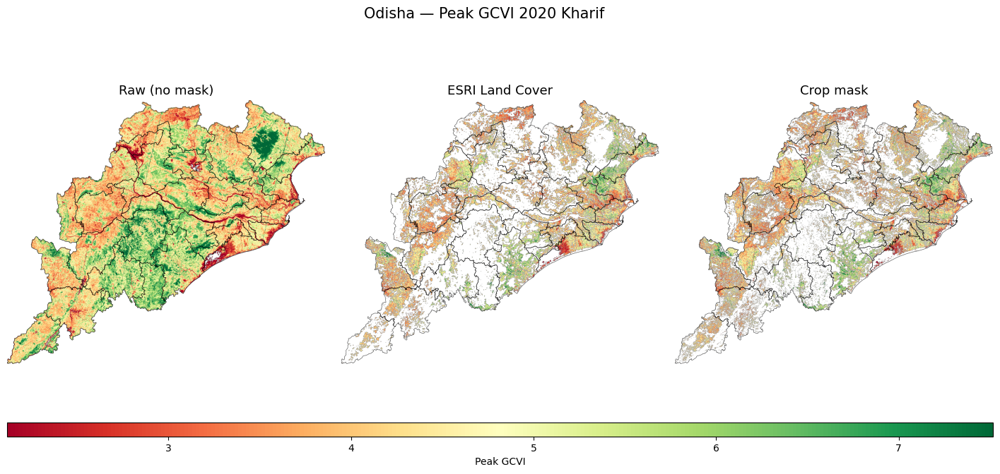

  Saved outputs/tif_viz_odisha.png


/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_29390/873178766.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


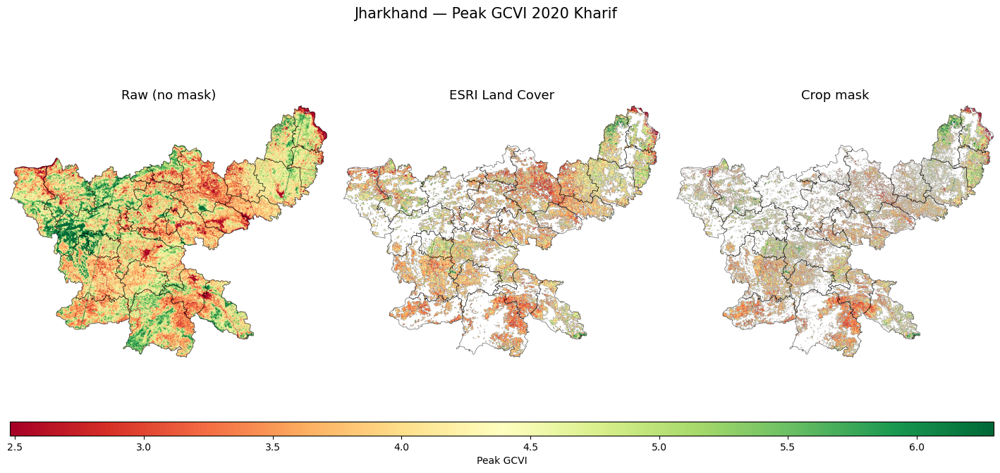

  Saved outputs/tif_viz_jharkhand.png


/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_29390/873178766.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


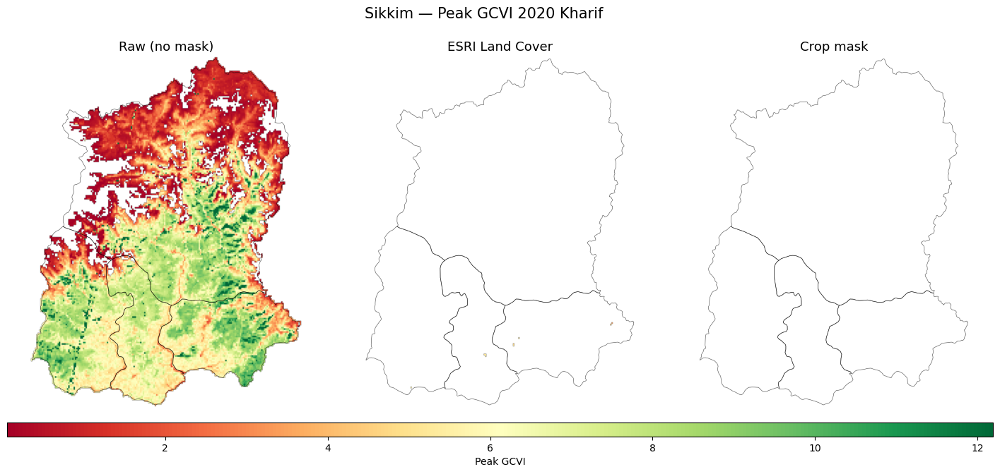

  Saved outputs/tif_viz_sikkim.png


/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_29390/873178766.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


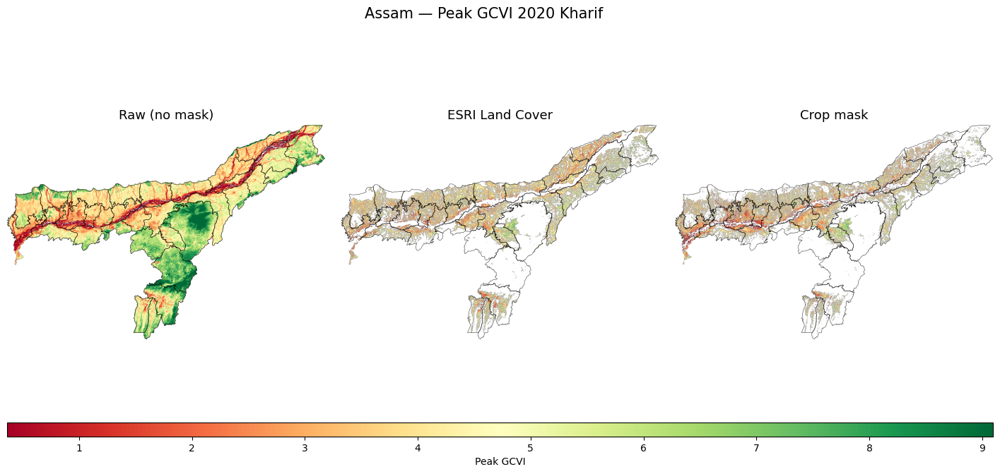

  Saved outputs/tif_viz_assam.png


/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_29390/873178766.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


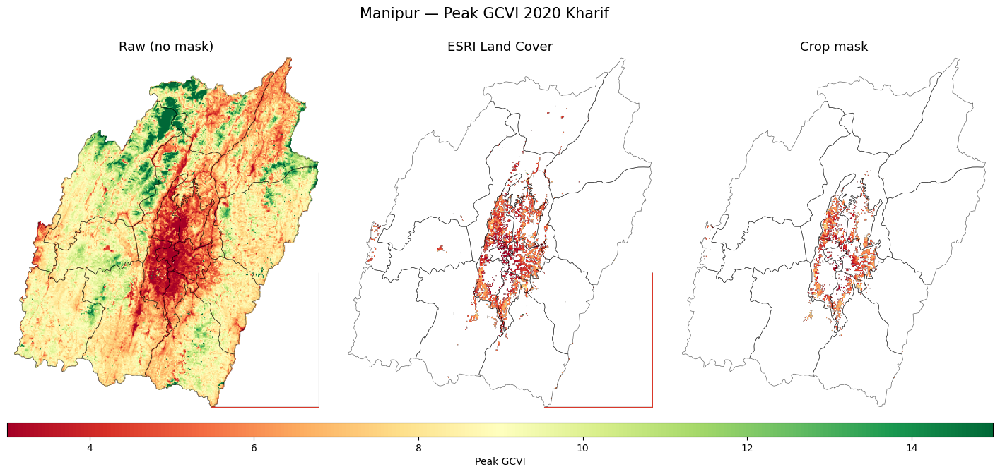

  Saved outputs/tif_viz_manipur.png


/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_29390/873178766.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


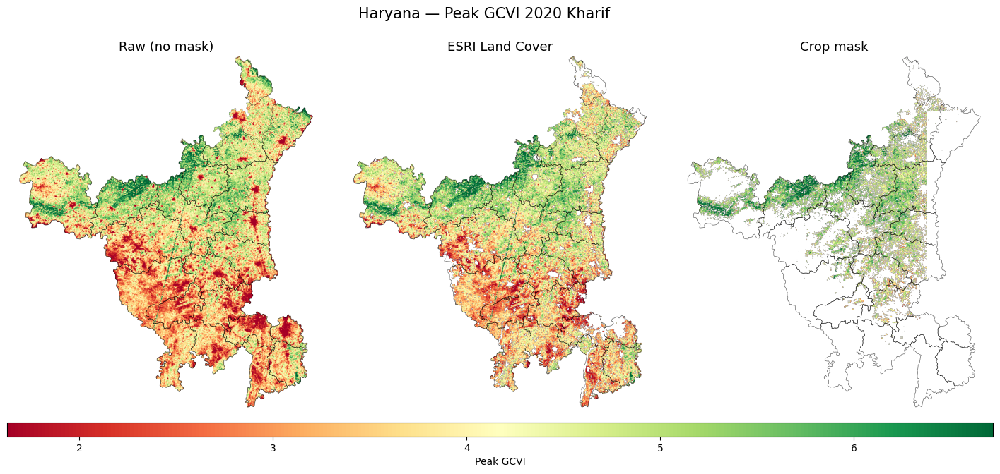

  Saved outputs/tif_viz_haryana.png


/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_29390/873178766.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


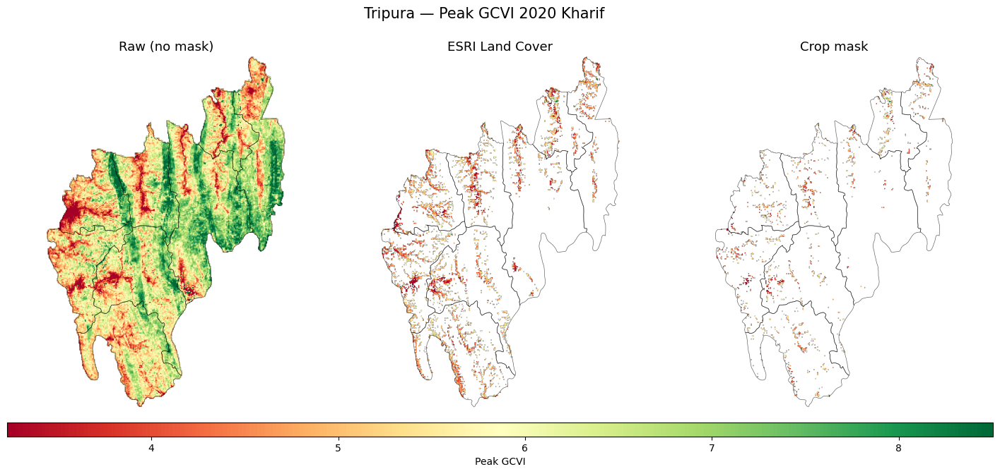

  Saved outputs/tif_viz_tripura.png


In [2]:
import os
import rasterio as rio
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

os.makedirs('outputs', exist_ok=True)

VIZ_YEAR = 2020

MASK_LABELS = {
    'raw':   'Raw (no mask)',
    'esri':  'ESRI Land Cover',
    'crop':  'Crop mask',
    'jordi': 'Crop mask',
}

STATE_LABELS = {
    'punjab':         'Punjab',
    'mp':             'Madhya Pradesh',
    'up':             'Uttar Pradesh',
    'wb':             'West Bengal',
    'telangana':      'Telangana',
    'maharashtra':    'Maharashtra',
    'karnataka':      'Karnataka',
    'andhra_pradesh': 'Andhra Pradesh',
    'tamil_nadu':     'Tamil Nadu',
    'odisha':         'Odisha',
    'jharkhand':      'Jharkhand',
    'sikkim':         'Sikkim',
    'assam':          'Assam',
    'manipur':        'Manipur',
    'haryana':        'Haryana',
    'tripura':        'Tripura',
}

# Punjab/MP use 'crop'; UP/WB and new states use 'jordi'
STATE_MASKS = {
    'punjab': ['raw', 'esri', 'crop'],
    'mp':     ['raw', 'esri', 'crop'],
    'up':     ['raw', 'esri', 'jordi'],
    'wb':     ['raw', 'esri', 'jordi'],
}
for s in STATE_LABELS:
    if s not in STATE_MASKS:
        STATE_MASKS[s] = ['raw', 'esri', 'jordi']

BDY = '../../data/district_boundaries'
BOUNDARY_FILES = {
    'punjab':         f'{BDY}/Punjab_Districts_GAUL.geojson',
    'mp':             f'{BDY}/Madhya_Pradesh_Districts_GAUL.geojson',
    'up':             f'{BDY}/UP_Districts_GAUL.geojson',
    'wb':             f'{BDY}/WB_Districts_GAUL.geojson',
    'telangana':      f'{BDY}/Telangana_Districts_GAUL.geojson',
    'maharashtra':    f'{BDY}/Maharashtra_Districts_GAUL.geojson',
    'karnataka':      f'{BDY}/Karnataka_Districts_GAUL.geojson',
    'andhra_pradesh': f'{BDY}/Andhra_Pradesh_Districts_GAUL.geojson',
    'tamil_nadu':     f'{BDY}/Tamil_Nadu_Districts_GAUL.geojson',
    'odisha':         f'{BDY}/Odisha_Districts_GAUL.geojson',
    'jharkhand':      f'{BDY}/Jharkhand_Districts_GAUL.geojson',
    'sikkim':         f'{BDY}/Sikkim_Districts_GAUL.geojson',
    'assam':          f'{BDY}/Assam_Districts_GAUL.geojson',
    'manipur':        f'{BDY}/Manipur_Districts_GAUL.geojson',
    'haryana':        f'{BDY}/Haryana_Districts_GAUL.geojson',
    'tripura':        f'{BDY}/Tripura_Districts_GAUL.geojson',
}

for state in STATE_LABELS:
    masks = STATE_MASKS[state]
    gdf   = gpd.read_file(BOUNDARY_FILES[state]).to_crs('EPSG:4326')

    # ── load rasters ──────────────────────────────────────────────────────
    arrays, extents = {}, {}
    for mask in masks:
        path = f'../../data/gcvi/peak_gcvi_kharif_{VIZ_YEAR}_{state}_{mask}.tif'
        if not os.path.exists(path):
            print(f'  Missing: {path}')
            arrays[mask] = None
            continue
        with rio.open(path) as src:
            data   = src.read(1).astype(float)
            nodata = src.nodata
            b      = src.bounds
        data[np.isinf(data)] = np.nan
        if nodata is not None:
            data[data == nodata] = np.nan
        data[data < 0] = np.nan
        arrays[mask]  = data
        extents[mask] = [b.left, b.right, b.bottom, b.top]

    # ── shared colour scale ───────────────────────────────────────────────
    all_vals = np.concatenate([a.ravel() for a in arrays.values() if a is not None])
    all_vals = all_vals[np.isfinite(all_vals)]
    if len(all_vals) == 0:
        print(f'  No valid pixels for {state}, skipping.')
        continue
    vmin, vmax = np.nanpercentile(all_vals, 2), np.nanpercentile(all_vals, 98)

    # ── layout: map row + thin colorbar row ───────────────────────────────
    fig = plt.figure(figsize=(18, 7))
    gs  = gridspec.GridSpec(2, 3, figure=fig,
                            height_ratios=[10, 0.4], hspace=0.08, wspace=0.05)
    last_im = None

    for col, mask in enumerate(masks):
        ax   = fig.add_subplot(gs[0, col])
        data = arrays.get(mask)
        if data is None:
            ax.text(0.5, 0.5, 'No file', ha='center', va='center',
                    transform=ax.transAxes, fontsize=12, color='grey')
            ax.axis('off')
            continue

        im = ax.imshow(data, cmap='RdYlGn', vmin=vmin, vmax=vmax,
                       extent=extents[mask], origin='upper', aspect='equal')
        gdf.boundary.plot(ax=ax, linewidth=0.5, edgecolor='black', alpha=0.6)
        ax.set_xlim(extents[mask][0], extents[mask][1])
        ax.set_ylim(extents[mask][2], extents[mask][3])
        ax.set_title(MASK_LABELS[mask], fontsize=13)
        ax.axis('off')
        last_im = im

    if last_im is not None:
        cbar_ax = fig.add_subplot(gs[1, :])
        fig.colorbar(last_im, cax=cbar_ax, orientation='horizontal', label='Peak GCVI')

    fig.suptitle(f'{STATE_LABELS[state]} — Peak GCVI {VIZ_YEAR} Kharif', fontsize=15)
    plt.tight_layout()

    out_path = f'outputs/tif_viz_{state}.png'
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Saved {out_path}')